# Deliverable 5 — Joining Airbnb + Bond data via Koordinates SA2 lookup
Everything from the brief is here, including both bonus items:
  - Bed-count comparison (Airbnb proxy vs. bond `Number Of Beds`)
  - SQLite + SQL join

Requires, in the same folder: `Airbnb_Oct25_Jun26.csv` (Deliverable 3),
`bond_data_clean.parquet` and `christchurch_sa2_lookup.csv` (Deliverable 4).
To run the API queries you also need your own key in `koordinates_key.txt`
(listed in `.gitignore`); if `sa2_cache.csv` exists, Step 2 makes no API calls.

In [1]:
import os
import time
import sqlite3
import requests
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

# ============================================================================
# CONFIG
# ============================================================================
# Each teammate keeps their own key in koordinates_key.txt (listed in .gitignore),
# so the key never appears in the notebook or on GitHub.
API_KEY = "YOUR API KEY"

LAYER = 123515  # Statistical Area 2 2026, from koordinates.com
QUERY_URL = "https://datafinder.stats.govt.nz/services/query/v1/vector.json"

AIRBNB_FILE = "Airbnb_Oct25_Jun26.csv"
BOND_FILE = "bond_data_clean.parquet"
LOOKUP_FILE = "christchurch_sa2_lookup.csv"
CACHE_FILE = "sa2_cache.csv"
AIRBNB_WITH_SA2_FILE = "Airbnb_with_sa2.csv"

MAX_WORKERS = 10          # concurrent requests
REQUEST_TIMEOUT = 30
RETRY_ATTEMPTS = 3

## Step 1 — Single-query test (do this before running thousands)

In [2]:
def get_sa2(lat, lon, session=None):
    """Query Koordinates for the SA2 code at a lat/lon point.
    Uses a small search radius so points that fall right on a
    boundary/coastline still resolve to the nearest polygon."""
    http = session or requests
    for attempt in range(RETRY_ATTEMPTS):
        try:
            r = http.get(QUERY_URL, params={
                "key": API_KEY, "layer": LAYER,
                "x": lon, "y": lat,
                "max_results": 1, "radius": 100, "geometry": "false",
            }, timeout=REQUEST_TIMEOUT)
            r.raise_for_status()
            props = r.json()["vectorQuery"]["layers"][str(LAYER)]["features"][0]["properties"]
            return props["SA22026_V1_00"]
        except (requests.RequestException, KeyError, IndexError) as e:
            if attempt == RETRY_ATTEMPTS - 1:
                print(f"  failed for ({lat}, {lon}) after {RETRY_ATTEMPTS} attempts: {e}")
                return None
            time.sleep(1.5 * (attempt + 1))  # backoff before retrying


print("Single-query test:", get_sa2(-43.531, 172.636))  # should print 326600

Single-query test: 326600


## Step 2 — Query all unique Airbnb coordinates, in parallel, with caching

Two efficiency decisions worth documenting in your README:
 1. We query only *unique* (lat, lon) pairs, not all 28,795 rows - the same
    listing repeats every month, so this cuts ~7x the API calls needed.
 2. We use a **thread pool**, not a process pool. The brief says
    "multi-processing", but these queries are I/O-bound (waiting on network
    responses), not CPU-bound - threads achieve the actual goal (parallel
    speedup) without the extra memory/serialization overhead a process
    pool would add for a task this size.
Results are cached to disk incrementally, so re-running this cell after an
interruption only queries what's still missing.

In [3]:
air = pd.read_csv(AIRBNB_FILE)
print(len(air), "Airbnb rows,", air.shape[1], "columns")

pts = air[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
print(len(pts), "unique coordinate pairs to query")

if os.path.exists(CACHE_FILE):
    cache_df = pd.read_csv(CACHE_FILE)
    cache_df["latitude"] = pd.to_numeric(cache_df["latitude"], errors="coerce")
    cache_df["longitude"] = pd.to_numeric(cache_df["longitude"], errors="coerce")
    done_points = set(zip(cache_df["latitude"], cache_df["longitude"]))
    results = cache_df.to_dict("records")
else:
    done_points = set()
    results = []

todo = [(float(r.latitude), float(r.longitude)) for r in pts.itertuples()
        if (float(r.latitude), float(r.longitude)) not in done_points]
print(f"already cached: {len(done_points)}  remaining: {len(todo)}")

session = requests.Session()
completed = 0
SAVE_EVERY = 200

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    future_to_point = {pool.submit(get_sa2, lat, lon, session): (lat, lon) for lat, lon in todo}
    for future in as_completed(future_to_point):
        lat, lon = future_to_point[future]
        code = future.result()
        results.append({"latitude": lat, "longitude": lon, "area_code": code})
        completed += 1
        if completed % SAVE_EVERY == 0:
            pd.DataFrame(results).to_csv(CACHE_FILE, index=False)
            print(f"saved {completed} / {len(todo)}")

sa2_cache = pd.DataFrame(results)
sa2_cache.to_csv(CACHE_FILE, index=False)
print("codes found:", sa2_cache["area_code"].notna().sum(), "of", len(sa2_cache))

28795 Airbnb rows, 19 columns
3956 unique coordinate pairs to query
already cached: 3956  remaining: 0
codes found: 3956 of 3956


## Step 3 — Attach area codes to the full Airbnb dataset & save

In [4]:
air["lat_k"] = air["latitude"].round(6)
air["lon_k"] = air["longitude"].round(6)
sa2_cache["lat_k"] = pd.to_numeric(sa2_cache["latitude"], errors="coerce").round(6)
sa2_cache["lon_k"] = pd.to_numeric(sa2_cache["longitude"], errors="coerce").round(6)

# one row per point so the merge can't accidentally multiply rows
sa2_lookup_by_point = sa2_cache.drop_duplicates(["lat_k", "lon_k"])[["lat_k", "lon_k", "area_code"]]

n_before_merge = len(air)
air = air.merge(sa2_lookup_by_point, on=["lat_k", "lon_k"], how="left")
assert len(air) == n_before_merge, (
    f"row count changed after SA2 merge: {n_before_merge} -> {len(air)} "
    "(sa2_lookup_by_point is not one-to-one on lat_k/lon_k)"
)
print(len(air), "rows (unchanged by the merge)")
print("rows with an area code:", air["area_code"].notna().sum())
print("unique SA2s touched by Airbnb listings:", air["area_code"].nunique())

air["area_code"] = pd.to_numeric(air["area_code"], errors="coerce")
air.to_csv(AIRBNB_WITH_SA2_FILE, index=False)

28795 rows (unchanged by the merge)
rows with an area code: 28795
unique SA2s touched by Airbnb listings: 178


## Step 4 — Prepare the bond side and pick a join type

In [5]:
bond = pd.read_parquet(BOND_FILE)

# Use the "ALL dwelling types, ALL bed counts" rows for the area-level rent
# comparison - this gives one clean rent figure per area/quarter rather than
# fragmenting into house/apartment/room subtypes we're not asking about here.
bond_all = bond[bond["Dwelling Type"].astype(str).str.upper() == "ALL"].copy()
beds_col = bond_all["Number Of Beds"].astype(str).str.upper()
if beds_col.eq("ALL").any():
    bond_all = bond_all[beds_col.eq("ALL")]

bond_all["period"] = pd.to_datetime(bond_all["TimeFrame"]).dt.to_period("Q").astype(str)
air["period"] = pd.to_datetime(air["month_year"].astype(str) + "-01").dt.to_period("Q").astype(str)

bond_one = (bond_all
    .groupby(["Location Id", "period"], as_index=False)
    .agg(median_rent=("Median Rent", "first"),
         active_bonds=("Active Bonds", "first"))
)
bond_one["rent_per_night"] = bond_one["median_rent"] / 7  # weekly -> nightly
# Using Median Rent so both sides use the same statistic (Airbnb median vs.
# bond median). Tenancy Services recommends Geometric Mean Rent for tracking
# rents over time, because rents cluster at round numbers ($400, $450) and
# medians "plateau"; for a single-period comparison like ours, the median is
# a fair like-for-like choice.

# --- Choosing the join type ---
# INNER keeps only rows where both an SA2 match AND a bond record exist for
# that quarter - every remaining row is directly usable for the price-gap
# comparison. LEFT keeps every Airbnb row but leaves rent columns blank for
# ~24% of them (areas/quarters with no matching bond data - see Deliverable
# 4's documented SA2 vintage-mismatch limitation). Since the gap analysis
# NEEDS both prices to mean anything, INNER is the suitable choice for the
# gap - LEFT would only add rows that can't form a gap. The counts in Step 5c
# deliberately keep every area instead (pd.concat), because areas with
# Airbnbs but no bond data are part of that answer.
inner_join = air.merge(bond_one, left_on=["area_code", "period"],
                        right_on=["Location Id", "period"], how="inner")
left_join = air.merge(bond_one, left_on=["area_code", "period"],
                       right_on=["Location Id", "period"], how="left")

print("Airbnb rows:             ", len(air))
print("INNER join rows:         ", len(inner_join), f"({len(inner_join)/len(air):.1%})")
print("LEFT join rows:          ", len(left_join))
print("LEFT rows w/ no bond rent:", left_join["median_rent"].isna().sum())
print("SA2s kept: INNER", inner_join["area_code"].nunique(), "| LEFT", left_join["area_code"].nunique())
print("-> INNER join for the price gap (Step 5b); Step 5c keeps every area")

merged = inner_join

Airbnb rows:              28795
INNER join rows:          21946 (76.2%)
LEFT join rows:           28795
LEFT rows w/ no bond rent: 6849
SA2s kept: INNER 122 | LEFT 178
-> INNER join for the price gap (Step 5b); Step 5c keeps every area


## Step 5a — Median Airbnb price in Christchurch Central (SA2 326600)

In [6]:
# Prices outside $20-$800/night are treated as data errors or non-representative
# luxury outliers (see Deliverable 4/Week 3 findings on extreme price values)
# and excluded from this specific summary stat only - the underlying dataset
# is untouched.
PRICE_MIN, PRICE_MAX = 20, 800

central_prices = air.loc[air["area_code"] == 326600, "price"]
central_prices = central_prices[(central_prices > PRICE_MIN) & (central_prices < PRICE_MAX)]
n_central_listings = air.loc[central_prices.index, "id"].nunique()
print(f"Christchurch Central (326600): median price ${central_prices.median():.0f}/night, "
      f"n={central_prices.size} listing-months from {n_central_listings} distinct listings")

Christchurch Central (326600): median price $237/night, n=701 listing-months from 150 distinct listings


## Step 5b — Where is the short- vs. long-term rental gap largest?

Largest median Airbnb premium over long-term rent (n = listing-months, n >= 20):
 area_code                           sa2_name  median_gap   n  listings
    322600                           Holmwood  209.571426  71        17
    322100                            Malvern  194.571426  84        17
    330500                             Ensors  187.000000  41         8
    322500                       Wigram North  183.714287  41         9
    324100                        Wigram East  183.000000  29         6
    325700          Christchurch Central-West  173.571426 709       140
    332700                             Sumner  173.428574 301        74
    319400                      Papanui North  171.000000  20         5
    332100                          Redcliffs  170.142860 145        35
    326800 Richmond South (Christchurch City)  161.785713 120        32


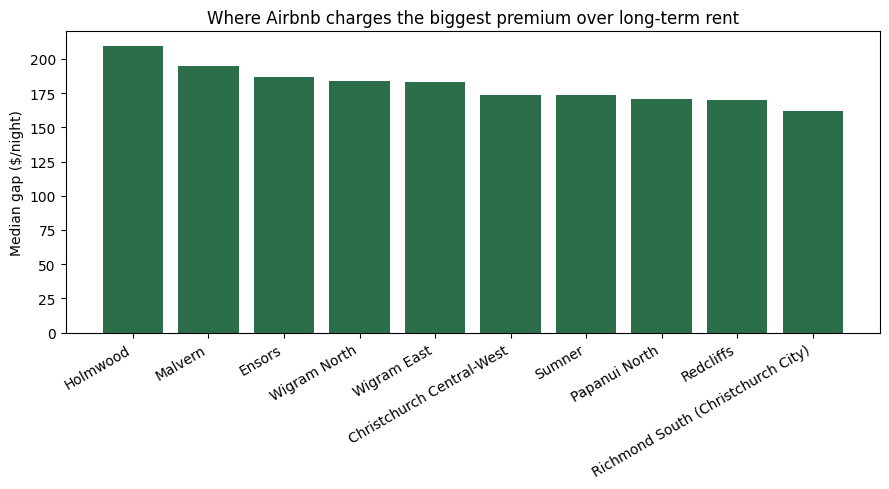

In [7]:
gap_df = merged.dropna(subset=["price", "rent_per_night"]).copy()
gap_df = gap_df[(gap_df["price"] > PRICE_MIN) & (gap_df["price"] < PRICE_MAX)]
gap_df["gap"] = gap_df["price"] - gap_df["rent_per_night"]

MIN_LISTINGS_PER_AREA = 20  # ignore areas with fewer than 20 listing-months (n) - too few to be reliable

gap_by_area = (gap_df.groupby("area_code")
               .agg(median_gap=("gap", "median"), n=("gap", "size"),
                    listings=("id", "nunique"))
               .query("n >= @MIN_LISTINGS_PER_AREA")
               .sort_values("median_gap", ascending=False))

lookup = pd.read_csv(LOOKUP_FILE)
gap_named = (gap_by_area.head(10).reset_index()
             .merge(lookup, left_on="area_code", right_on="sa2_code", how="left"))
print("Largest median Airbnb premium over long-term rent (n = listing-months, n >= 20):")
print(gap_named[["area_code", "sa2_name", "median_gap", "n", "listings"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(gap_named["sa2_name"].fillna(gap_named["area_code"].astype(str)),
       gap_named["median_gap"], color="#2c6e49")
ax.set_ylabel("Median gap ($/night)")
ax.set_title("Where Airbnb charges the biggest premium over long-term rent")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig("gap_median_bar.png", dpi=150)
plt.show()

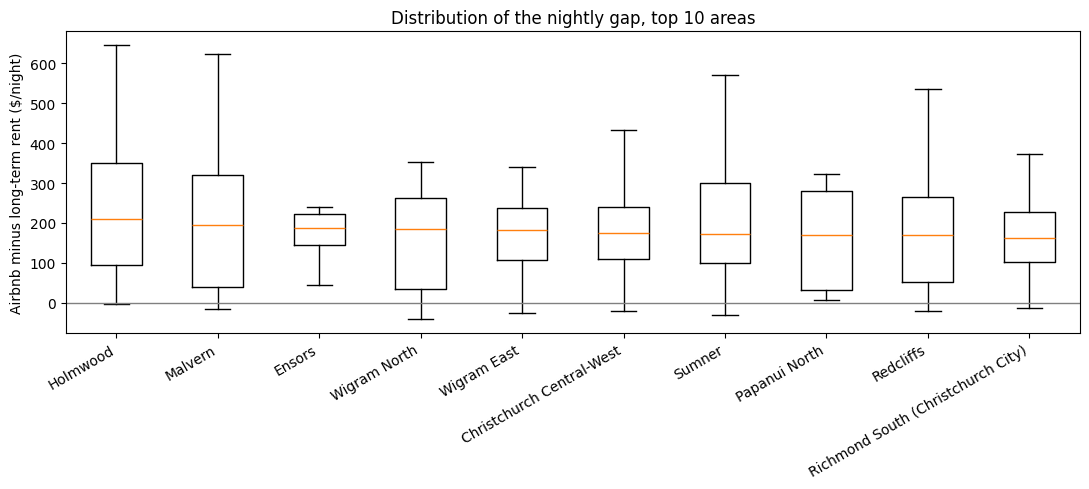

In [8]:
# Distribution of the gap in each of the top-10 areas (the brief asks to plot
# the distribution per location id, not just the median). Box = middle 50% of
# values, line = median, whiskers = typical range; extreme outliers hidden.
dist_data = [gap_df.loc[gap_df["area_code"] == a, "gap"].values for a in gap_named["area_code"]]
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(dist_data, showfliers=False)
ax.set_xticks(range(1, len(dist_data) + 1))
ax.set_xticklabels(gap_named["sa2_name"].fillna(gap_named["area_code"].astype(str)),
                   rotation=30, ha="right")
ax.axhline(0, color="grey", lw=1)
ax.set_ylabel("Airbnb minus long-term rent ($/night)")
ax.set_title("Distribution of the nightly gap, top 10 areas")
fig.tight_layout()
fig.savefig("gap_distribution_box.png", dpi=150)
plt.show()

## Step 5c — Airbnb listings vs. long-term rentals per area

In [9]:
# Count each listing once per quarter, then take the median quarter - the same
# "typical quarter" basis as the bond side (Active Bonds is a per-quarter figure).
listings_per_area = (air.drop_duplicates(["id", "period"])
                        .groupby(["area_code", "period"]).size()
                        .groupby("area_code").median()
                        .rename("n_airbnb_listings"))
bonds_per_area = bond_one.groupby("Location Id")["active_bonds"].median().rename("n_active_bonds")

counts = pd.concat([listings_per_area, bonds_per_area], axis=1)
counts = counts.merge(lookup, left_index=True, right_on="sa2_code", how="left").set_index("sa2_code")
counts = counts.sort_values("n_airbnb_listings", ascending=False)
print(counts.head(15).to_string())

          n_airbnb_listings  n_active_bonds                    sa2_name
sa2_code                                                               
327000                325.0           960.0   Christchurch Central-East
327100                252.0           261.0  Christchurch Central-South
325800                172.0          1131.0  Christchurch Central-North
326600                140.0            42.0        Christchurch Central
325700                132.0           444.0   Christchurch Central-West
333500                105.0             NaN                      Akaroa
333300                 88.0             NaN                         NaN
332700                 68.0           258.0                      Sumner
323000                 65.0           651.0                    Merivale
332501                 58.0             NaN                         NaN
324800                 50.0          1002.0              St Albans East
323900                 47.0           702.0              St Alba

## BONUS 1 — Comparing beds: Airbnb vs. long-term rental

**Limitation, stated up front:** the Airbnb dataset has no bedroom-count
column (`room_type` is the closest field, e.g. "Entire home/apt" vs.
"Private room"). A true bed-for-bed comparison against the bond data's
`Number Of Beds` breakdown isn't possible without that field. What follows
is a **rough proxy** using `room_type` as a stand-in for bedroom count, not
an exact count - treat it as directional, not precise.

In [10]:
# --- Parameters (adjust here) ---
MIN_BOND_COVERAGE = 0.8        # published bedroom categories must cover >= 80% of an area's active bonds
MIN_LISTINGS_PER_QUARTER = 10  # ignore areas with fewer Airbnb listings than this in a typical quarter

room_type_bed_proxy = {
    "Entire home/apt": 2,   # assume ~2BR average for a whole home, unverified
    "Private room": 1,
    "Shared room": 1,
    "Hotel room": 1,
}
air["approx_beds"] = air["room_type"].map(room_type_bed_proxy).fillna(1)

# Airbnb side: count each listing ONCE per quarter (the panel has one row per
# listing per month), take the MEAN bedrooms per listing in each area/quarter
# (typical property size, not total volume), then the median quarter.
air_by_quarter = air.drop_duplicates(["id", "period"]).groupby(["area_code", "period"])["approx_beds"]
mean_airbnb_beds_per_area = air_by_quarter.mean().groupby("area_code").median().rename("mean_airbnb_bedrooms")
airbnb_listings_per_quarter = air_by_quarter.size().groupby("area_code").median().rename("airbnb_listings_per_quarter")

# Bond side: use the actual bed-count breakdown (excluding the "ALL" rollup row
# so we don't double count). "5+" counted as 5, so this is a lower bound.
bond_by_beds = bond[bond["Dwelling Type"].astype(str).str.upper() == "ALL"].copy()
bond_by_beds = bond_by_beds[bond_by_beds["Number Of Beds"].astype(str).str.upper() != "ALL"]
bond_by_beds["period"] = pd.to_datetime(bond_by_beds["TimeFrame"]).dt.to_period("Q").astype(str)
bond_by_beds["beds_n"] = pd.to_numeric(bond_by_beds["Number Of Beds"].astype(str).str.rstrip("+"),
                                       errors="coerce")
bond_by_beds["bedrooms"] = bond_by_beds["beds_n"] * bond_by_beds["Active Bonds"]

# Rows with a blank bed count (unknown bedrooms) cannot contribute to an average, so
# they are excluded from BOTH the numerator and the denominator. Keeping them in the
# denominator only made some areas look like they had 0 bedrooms.
n_unknown_beds = bond_by_beds["beds_n"].isna().sum()
bond_known_beds = bond_by_beds.dropna(subset=["beds_n", "Active Bonds"])
print(f"Excluded {n_unknown_beds} bond rows with an unknown bed count from the bedroom mean.")

by_area_quarter = (bond_known_beds.groupby(["Location Id", "period"])[["bedrooms", "Active Bonds"]].sum())
by_area_quarter["mean_beds"] = by_area_quarter["bedrooms"] / by_area_quarter["Active Bonds"]

# Coverage = share of the area's total active bonds (from the ALL/ALL row) that have a
# published bed count. Low coverage means the mean would reflect only whichever
# categories survived Tenancy Services' privacy suppression.
all_bonds = (bond[(bond["Dwelling Type"].astype(str).str.upper() == "ALL") &
                  (bond["Number Of Beds"].astype(str).str.upper() == "ALL")]
             .assign(period=lambda d: pd.to_datetime(d["TimeFrame"]).dt.to_period("Q").astype(str))
             .set_index(["Location Id", "period"])["Active Bonds"])
by_area_quarter["coverage"] = by_area_quarter["Active Bonds"] / all_bonds
n_before = by_area_quarter.index.get_level_values("Location Id").nunique()
by_area_quarter = by_area_quarter[by_area_quarter["coverage"] >= MIN_BOND_COVERAGE]
n_after = by_area_quarter.index.get_level_values("Location Id").nunique()
print(f"Bond coverage filter (>= {MIN_BOND_COVERAGE:.0%}): {n_before} -> {n_after} areas.")

mean_long_term_beds_per_area = (by_area_quarter["mean_beds"].groupby("Location Id").median()
                                .rename("mean_long_term_bedrooms"))

bed_comparison = pd.concat([mean_airbnb_beds_per_area, airbnb_listings_per_quarter,
                            mean_long_term_beds_per_area], axis=1).dropna()
bed_comparison = bed_comparison[bed_comparison["airbnb_listings_per_quarter"] >= MIN_LISTINGS_PER_QUARTER]
bed_comparison = bed_comparison.merge(lookup, left_index=True, right_on="sa2_code", how="left").set_index("sa2_code")
bed_comparison["size_diff"] = bed_comparison["mean_airbnb_bedrooms"] - bed_comparison["mean_long_term_bedrooms"]
bed_comparison = bed_comparison.sort_values("size_diff", ascending=False)
print(f"\n{len(bed_comparison)} areas remain after both filters.")
print("Mean bedrooms per property in a typical quarter: Airbnb (estimated) vs. long-term rental (top 15 by size_diff):")
print(bed_comparison.head(15).to_string())
print("\nsize_diff > 0: Airbnb properties are larger on average than long-term rentals in that area.")
print("size_diff near 0: similar property sizes; the difference is about tenure, not size.")
print("\nCaveats: 'mean_airbnb_bedrooms' is a room_type-based estimate (between 1 and 2), not an exact count.")
print("'mean_long_term_bedrooms' is a lower bound: '5+' counts as 5, and small bedroom")
print("categories are suppressed by Tenancy Services for privacy.")
print("'Short-term' vs 'long-term' is decided by data source (Airbnb vs. Tenancy Services bonds),")
print("not by observed stay length, so long-stay Airbnb bookings still count as short-term here.")


Excluded 49 bond rows with an unknown bed count from the bedroom mean.
Bond coverage filter (>= 80%): 116 -> 30 areas.

26 areas remain after both filters.
Mean bedrooms per property in a typical quarter: Airbnb (estimated) vs. long-term rental (top 15 by size_diff):
          mean_airbnb_bedrooms  airbnb_listings_per_quarter  mean_long_term_bedrooms                            sa2_name  size_diff
sa2_code                                                                                                                           
327000                1.935211                        325.0                 1.559259           Christchurch Central-East   0.375952
326100                1.857143                         38.0                 1.556452                      Addington West   0.300691
325800                1.934673                        172.0                 1.717919          Christchurch Central-North   0.216755
323900                1.977273                         47.0             

          mean_airbnb_bedrooms  airbnb_listings_per_quarter  mean_long_term_bedrooms                            sa2_name  size_diff
sa2_code                                                                                                                           
327000                1.935211                        325.0                 1.559259           Christchurch Central-East   0.375952
326100                1.857143                         38.0                 1.556452                      Addington West   0.300691
325800                1.934673                        172.0                 1.717919          Christchurch Central-North   0.216755
323900                1.977273                         47.0                 1.927187                      St Albans West   0.050086
321400                2.000000                         12.0                 1.988235                             Strowan   0.011765
326800                1.913043                         23.0                 

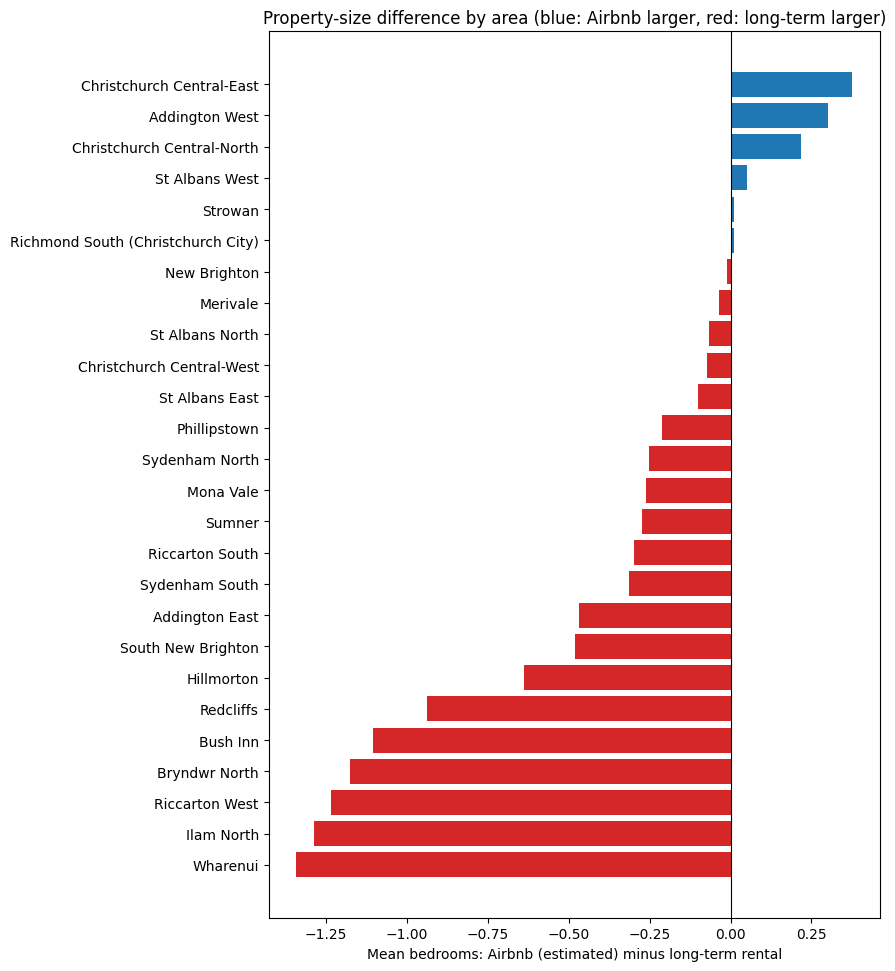

In [11]:
# Full Bonus 1 table (all areas that passed both filters) + chart of size_diff
print(bed_comparison.to_string())

plot_df = bed_comparison.sort_values("size_diff")
fig, ax = plt.subplots(figsize=(9, 0.32 * len(plot_df) + 1.5))
ax.barh(plot_df["sa2_name"], plot_df["size_diff"],
        color=["tab:red" if v < 0 else "tab:blue" for v in plot_df["size_diff"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean bedrooms: Airbnb (estimated) minus long-term rental")
ax.set_title("Property-size difference by area (blue: Airbnb larger, red: long-term larger)")
plt.tight_layout()
fig.savefig("bedroom_size_diff_bar.png", dpi=150)
plt.show()

## BONUS 2 — SQLite + SQL join

Loads both cleaned datasets into a local SQLite file and reproduces the
Step 4 inner join using SQL instead of pandas, as a cross-check.

In [12]:
DB_PATH = "christchurch_housing.db"
conn = sqlite3.connect(DB_PATH)

air.to_sql("airbnb", conn, if_exists="replace", index=False)
bond_one.to_sql("bond", conn, if_exists="replace", index=False)

sql_join_query = """
    SELECT a.*, b.median_rent, b.active_bonds, b.rent_per_night
    FROM airbnb AS a
    INNER JOIN bond AS b
        ON a.area_code = b."Location Id"
        AND a.period    = b.period
"""
sql_result = pd.read_sql_query(sql_join_query, conn)
conn.close()

print("SQL inner-join rows:   ", len(sql_result))
print("pandas inner-join rows:", len(inner_join))
assert len(sql_result) == len(inner_join), "SQL and pandas joins disagree - investigate!"
print("Match confirmed: SQL join reproduces the pandas join exactly.")

SQL inner-join rows:    21946
pandas inner-join rows: 21946
Match confirmed: SQL join reproduces the pandas join exactly.
